In [1]:
#Multi-Layer Perceptron

In [36]:
import pandas as pd

# Load training data
train_data = pd.read_csv("../data/train.csv")

# Separate features and labels
X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

# Normalize pixel values
X = X / 255.0

In [39]:
#Split the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(33600, 784)
(8400, 784)


In [40]:
#import the MLP

from sklearn.neural_network import MLPClassifier

In [46]:
# Model Building

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=50,
    random_state=42
)

In [47]:
# Training the data for the builded Model

mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [49]:
# Testing the builded Model

y_pred_mlp = mlp.predict(X_test)

In [52]:
# Performance Measure

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

# Precision
mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')

# Recall
mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')

# F1-score
mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')

print("MLP Accuracy     :", mlp_accuracy)

print("MLP Precision    :", mlp_precision)

print("MLP Recall       :", mlp_recall)

print("MLP F1-Score     :", mlp_f1)

MLP Accuracy     : 0.9742857142857143
MLP Precision    : 0.9742900300541578
MLP Recall       : 0.9742857142857143
MLP F1-Score     : 0.974275483251245


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.97      0.98      0.97       835
           3       0.97      0.96      0.96       870
           4       0.98      0.98      0.98       814
           5       0.97      0.97      0.97       759
           6       0.99      0.99      0.99       827
           7       0.98      0.97      0.98       880
           8       0.97      0.96      0.97       813
           9       0.95      0.96      0.96       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



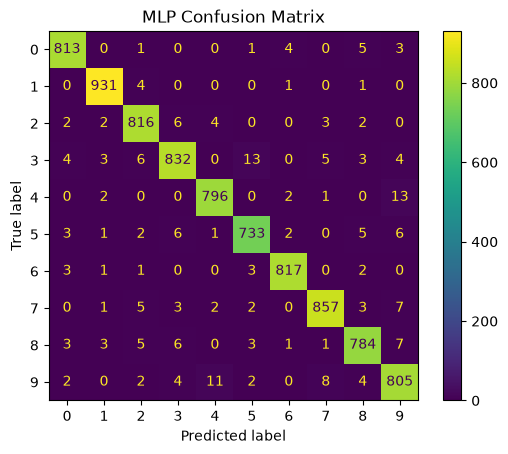

In [54]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_mlp)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot()
plt.title("MLP Confusion Matrix")
plt.show()

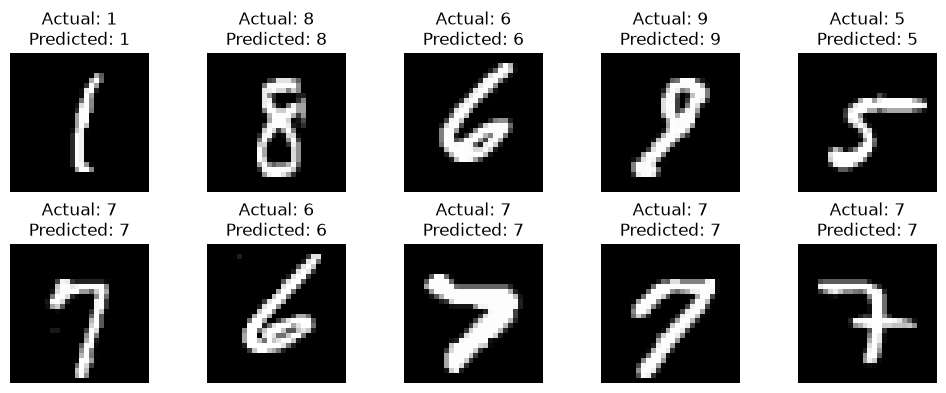

In [60]:
# Show some predictions visually

plt.figure(figsize=(10, 4))

for i in range(10):
    image = X_test.iloc[i].values.reshape(28, 28)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {y_test.iloc[i]}\nPredicted: {y_pred_mlp[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
# Save the trained MLP

import joblib

joblib.dump(mlp, "mlp_digit_model.pkl")

print("MLP model saved successfully!")

MLP model saved successfully!


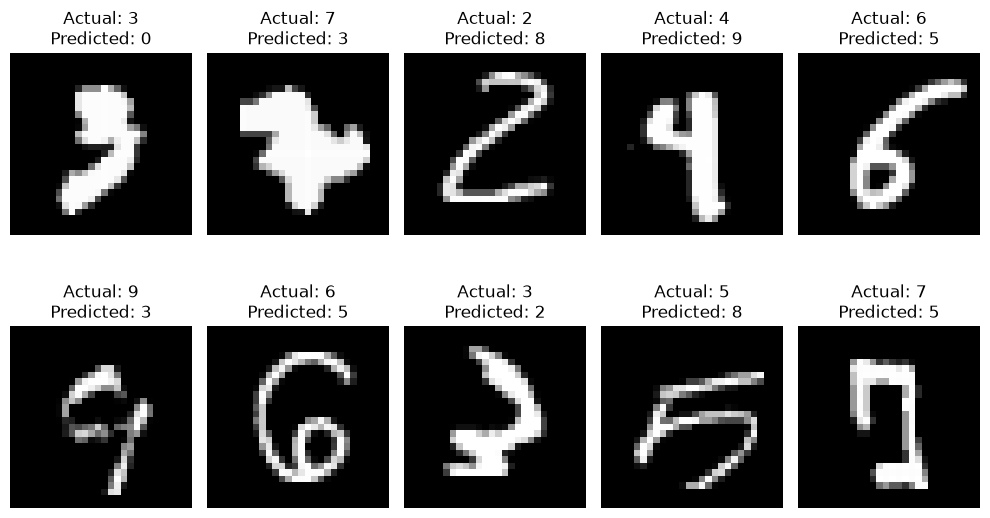

In [61]:
# See the Actual Mistakes

import matplotlib.pyplot as plt

wrong_indices = [i for i in range(len(y_test))
                 if y_test.iloc[i] != y_pred_mlp[i]]

plt.figure(figsize=(10, 6))

for j, i in enumerate(wrong_indices[:10]):
    image = X_test.iloc[i].values.reshape(28, 28)

    plt.subplot(2, 5, j + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"Actual: {y_test.iloc[i]}\nPredicted: {y_pred_mlp[i]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:

# MNIST train.csv
#       ↓
# Load dataset
#       ↓
# Separate Features (X) and Labels (y)
#       ↓
# X = Pixel values
# y = Actual digits (0–9)
#       ↓
# Normalize X
# X = X / 255.0
#       ↓
# Pixel values change
# 0–255  →  0–1
#       ↓
# Split the data
#       ↓
# ┌─────────────────────┬─────────────────────┐
# │ 80% Training data   │ 20% Testing data    │
# │                     │                     │
# │ X_train, y_train    │ X_test, y_test      │
# └─────────────────────┴─────────────────────┘
#       ↓
# Create MLP model
#       ↓
# 784 input neurons
#       ↓
# 128 hidden neurons
#       ↓
# 64 hidden neurons
#       ↓
# 10 output neurons
# (0,1,2,...9)
#       ↓
# Choose ReLU activation
#       ↓
# Choose Adam optimizer
#       ↓
# Train using:
# mlp.fit(X_train, y_train)
#       ↓
# Model sees an image
#       ↓
# Makes a prediction
#       ↓
# Compares prediction with actual label
#       ↓
# Calculates error
#       ↓
# Adam adjusts weights
#       ↓
# Model learns
#       ↓
# Repeat for training iterations
#       ↓
# Training complete
#       ↓
# Give X_test to model
#       ↓
# Model predicts digits
#       ↓
# Compare predictions with y_test
#       ↓
# Calculate accuracy
